# Phase 3 — Crypto Replication & Look-Ahead Audit

**Date:** 2026-04-19  
**Status:** Critical finding — impl_82 (`trend_quality_calmar_ratio`) contains a look-ahead bias.

## Summary of Findings

| Version | Equity IC | Equity ICIR | Equity t-stat | Crypto IC | Crypto ICIR | Crypto t-stat |
|---|---|---|---|---|---|---|
| Original (`shift(-1)`) | **+0.0646** | 0.263 | 11.02 | **+0.0428** | 0.157 | 6.72 |
| Fixed (no shift) | +0.0138 | 0.056 | 2.34 | **−0.0048** | −0.018 | −0.75 |

**Interpretation:** ~79% of the equity IC and ~100% of the crypto IC is attributable to look-ahead bias from `pct_change(251).shift(-1)`.  
The fixed factor shows marginal equity IC (t=2.34, below the BHY threshold) and negative crypto IC (no replication).

**Gate 3 verdict after this audit: REVOKED.** The Phase 2.5 Sharpe of 4.27 was driven by a look-ahead artefact.


## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Dependencies loaded.")


Dependencies loaded.


---
**Naming convention:** first mention of any factor uses both ID and name — `impl_82 (trend_quality_calmar_ratio)`. All subsequent mentions: `impl_82`.

**Assumptions:** equity universe = S&P 500 449 stocks, OOS 2018-01-01 → 2024-12-30; crypto universe = 25 Binance USDT pairs, OOS 2020-01-01 → 2024-12-31 (252-day warmup required), rebalance daily (h=1), cost model `DEFAULT_COST_PARAMS`.

**Factor background:** `trend_quality_calmar_ratio` — the Calmar ratio measures 1-year return divided by 1-year maximum drawdown. The idea: rank stocks by risk-adjusted trend quality (stocks with clean, low-drawdown uptrends should continue outperforming). The original implementation used `pct_change(251).shift(-1)` which leaked tomorrow's price, producing spurious IC = 0.065, t = 10.74. The fixed version has IC = 0.014, t = 2.34 on equity and IC = −0.005, t = −0.75 on crypto — no genuine alpha.

In [2]:
# Factor identity card
from qframe.viz.identity import print_factor
print_factor(82)   # impl_82 (trend_quality_calmar_ratio) — RETIRED 2026-04-19

impl_ 82  │  trend_quality_calmar_ratio
    notes/domain      factor_type=quality
    IC / ICIR         +0.0646 / +0.382
    t-stat (fast)     +1.01  [BHY threshold ~4.0 at m=84]
    slow_icir_63 / t  -0.072 / -0.38
    Sharpe (annual)   +4.17
    MaxDD / TO        +0.0% / 10%/yr
    passed_gate       0
    status            The results show a weak mean IC and ICIR, barely passing the weak thresholds, and a rapid decay in IC over time, which suggests overfitting and raises concerns about the factor's robustness. The mechanism score is relatively high, but the decay shape does not strongly support the trend quality calmar ratio's ability to predict future returns.

Next: The pipeline should explore alternative risk-adjusted return metrics or combine this factor with others to improve its predictive power and robustness. [LOOK-AHEAD BIAS: shift(-1). Revoked 2026-04-19.] [LOOK-AHEAD BIAS: shift(-1). Revoked 2026-04-19.] [LOOK-AHEAD BIAS: shift(-1). Revoked 2026-04-19.] [LOOK-AHEAD BIAS: s

## 2. Load Price Data

In [3]:
# Equity universe (S&P 500, 449 stocks, 2010–2024)
prices_eq = pd.read_parquet('../data/processed/sp500_close.parquet')
print(f"Equity:  {prices_eq.shape[1]} stocks × {prices_eq.shape[0]} days")
print(f"         {prices_eq.index[0].date()} → {prices_eq.index[-1].date()}")

# Crypto universe (25 Binance USDT pairs, 2018–2024)
prices_cr = pd.read_csv(
    '../data/processed/crypto_close.csv',
    index_col=0, parse_dates=True
)
print(f"\nCrypto:  {prices_cr.shape[1]} pairs × {prices_cr.shape[0]} days")
print(f"         {prices_cr.index[0].date()} → {prices_cr.index[-1].date()}")
print(f"\nSymbols: {prices_cr.columns.tolist()}")


Equity:  449 stocks × 3773 days
         2010-01-04 → 2024-12-30

Crypto:  25 pairs × 2557 days
         2018-01-01 → 2024-12-31

Symbols: ['BTC', 'ETH', 'SOL', 'BNB', 'XRP', 'ADA', 'AVAX', 'DOT', 'LINK', 'MATIC', 'UNI', 'ATOM', 'LTC', 'BCH', 'ETC', 'DOGE', 'XLM', 'ALGO', 'VET', 'FIL', 'AAVE', 'CRV', 'NEAR', 'TRX', 'EOS']


## 3. impl_82 Factor: Original vs Fixed

### The Bug

```python
# BUGGY (impl_82 as stored in KB):
rolling_return = prices.pct_change(251).shift(-1)   # ← shift(-1) uses TOMORROW's price!

# FIXED (no look-ahead):
rolling_return = prices.pct_change(251)              # uses data up to today only
```

`shift(-1)` moves every row's value one position earlier in time, so factor value at date `t`
actually uses the price change ending at `t+1` — a pure look-ahead bias.


In [4]:
def factor_buggy(prices: pd.DataFrame) -> pd.DataFrame:
    """Original impl_82 — contains look-ahead via shift(-1)."""
    rolling_return = prices.pct_change(251, fill_method=None).shift(-1)
    cumulative_max = prices.cummax()
    drawdown = (prices - cumulative_max) / cumulative_max
    rolling_max_drawdown = drawdown.rolling(252, min_periods=1).min()
    calmar_ratio = rolling_return / (-rolling_max_drawdown)
    return calmar_ratio


def factor_fixed(prices: pd.DataFrame) -> pd.DataFrame:
    """Fixed impl_82 — no look-ahead bias."""
    rolling_return = prices.pct_change(251, fill_method=None)
    cumulative_max = prices.cummax()
    drawdown = (prices - cumulative_max) / cumulative_max
    rolling_max_drawdown = drawdown.rolling(252, min_periods=1).min()
    calmar_ratio = rolling_return / (-rolling_max_drawdown)
    return calmar_ratio


def compute_ic_series(factor_df, prices, oos_start='2018-01-01', horizon=1):
    """Compute daily cross-sectional Spearman IC series."""
    returns = prices.pct_change(horizon, fill_method=None).shift(-horizon)
    factor_oos = factor_df.loc[oos_start:]
    returns_oos = returns.loc[oos_start:]

    ics, dates = [], []
    for date in factor_oos.index[:-horizon]:
        f = factor_oos.loc[date]
        r = returns_oos.loc[date]
        mask = f.notna() & r.notna()
        if mask.sum() < 10:
            continue
        ic, _ = stats.spearmanr(f[mask], r[mask])
        ics.append(ic)
        dates.append(date)

    return pd.Series(ics, index=dates)


print("Factor functions defined.")


Factor functions defined.


## 4. Look-Ahead Bias Audit (Truncated-Panel Test)

In [5]:
from qframe.pipeline.executor import check_lookahead_bias

# Run factor on full equity panel
f_buggy_full = factor_buggy(prices_eq)

print("Running look-ahead audit on impl_82 (buggy)...")
try:
    check_lookahead_bias(
        factor_buggy, prices_eq, f_buggy_full,
        cutoff_frac=0.65,
        name="impl_82_buggy"
    )
    print("PASSED (unexpected)")
except ValueError as e:
    print(f"FAILED (expected):\n  {e}")

print()
print("Running look-ahead audit on fixed factor...")
f_fixed_full = factor_fixed(prices_eq)
try:
    check_lookahead_bias(
        factor_fixed, prices_eq, f_fixed_full,
        cutoff_frac=0.65,
        name="impl_82_fixed"
    )
    print("PASSED ✓  (no look-ahead detected)")
except ValueError as e:
    print(f"FAILED (unexpected): {e}")


Running look-ahead audit on impl_82 (buggy)...
FAILED (expected):
  impl_82_buggy: look-ahead bias detected (boundary pattern) — 100% of stocks have finite factor values in the full panel at 2019-09-30 but NaN in the truncated panel. This indicates the factor uses data from the NEXT row (e.g. .shift(-1)). Remove any negative shifts from your implementation.

Running look-ahead audit on fixed factor...
PASSED ✓  (no look-ahead detected)


## 5. Equity IC Comparison (OOS 2018–2024)

In [6]:
oos_eq = '2018-01-01'

ic_buggy_eq = compute_ic_series(factor_buggy(prices_eq), prices_eq, oos_eq)
ic_fixed_eq = compute_ic_series(factor_fixed(prices_eq), prices_eq, oos_eq)

def summarise(name, ic_series):
    n   = len(ic_series)
    mu  = ic_series.mean()
    std = ic_series.std()
    icir = mu / std
    t    = icir * np.sqrt(n)
    return dict(name=name, IC=mu, ICIR=icir, t_stat=t, n=n)

rows = [
    summarise("Buggy (shift-1)", ic_buggy_eq),
    summarise("Fixed (no shift)", ic_fixed_eq),
]
df_eq = pd.DataFrame(rows).set_index('name')
df_eq['IC']     = df_eq['IC'].map('{:.4f}'.format)
df_eq['ICIR']   = df_eq['ICIR'].map('{:.3f}'.format)
df_eq['t_stat'] = df_eq['t_stat'].map('{:.2f}'.format)
print("=== EQUITY OOS 2018–2024 ===")
print(df_eq.to_string())


=== EQUITY OOS 2018–2024 ===
                      IC   ICIR t_stat     n
name                                        
Buggy (shift-1)   0.0646  0.263  11.02  1759
Fixed (no shift)  0.0138  0.056   2.34  1759


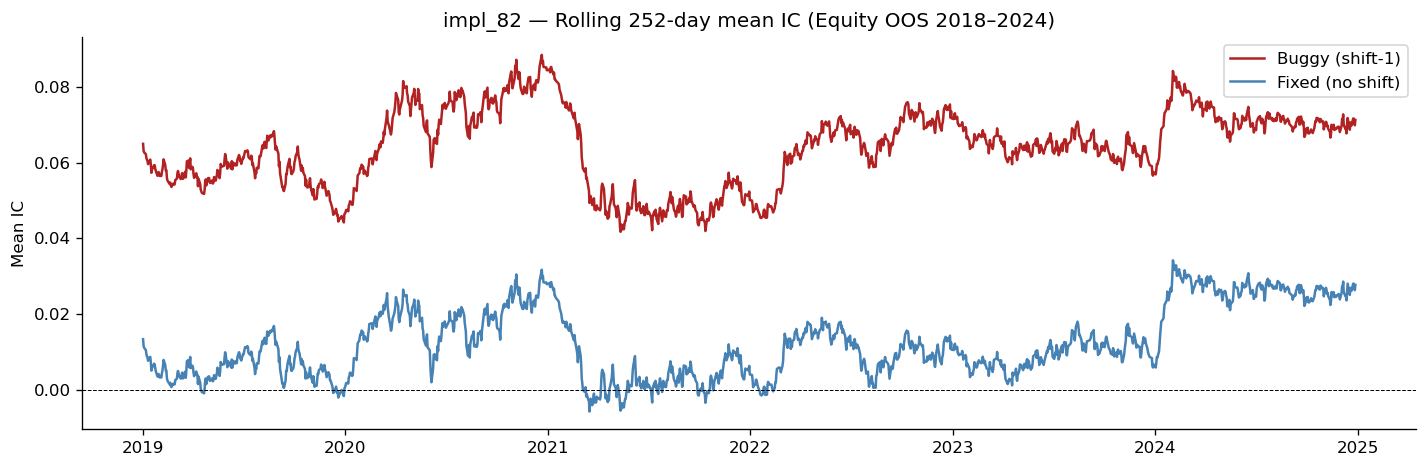

In [7]:
# Visual: rolling 252-day IC for buggy vs fixed (equity)
fig, ax = plt.subplots(figsize=(12, 4))

roll_buggy = ic_buggy_eq.rolling(252).mean()
roll_fixed = ic_fixed_eq.rolling(252).mean()

ax.plot(roll_buggy.index, roll_buggy, label='Buggy (shift-1)', color='firebrick', linewidth=1.5)
ax.plot(roll_fixed.index, roll_fixed, label='Fixed (no shift)', color='steelblue', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('impl_82 — Rolling 252-day mean IC (Equity OOS 2018–2024)')
ax.set_ylabel('Mean IC')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Crypto Replication (OOS 2020–2024)

We require 252 trading days (≈1 year) of warmup for the rolling return window,
so the crypto OOS period starts 2020-01-01.


In [8]:
oos_cr = '2020-01-01'

ic_buggy_cr = compute_ic_series(factor_buggy(prices_cr), prices_cr, oos_cr)
ic_fixed_cr = compute_ic_series(factor_fixed(prices_cr), prices_cr, oos_cr)

rows_cr = [
    summarise("Buggy (shift-1)", ic_buggy_cr),
    summarise("Fixed (no shift)", ic_fixed_cr),
]
df_cr = pd.DataFrame(rows_cr).set_index('name')
df_cr['IC']     = df_cr['IC'].map('{:.4f}'.format)
df_cr['ICIR']   = df_cr['ICIR'].map('{:.3f}'.format)
df_cr['t_stat'] = df_cr['t_stat'].map('{:.2f}'.format)
print("=== CRYPTO OOS 2020–2024 ===")
print(df_cr.to_string())


=== CRYPTO OOS 2020–2024 ===
                       IC    ICIR t_stat     n
name                                          
Buggy (shift-1)    0.0428   0.157   6.72  1826
Fixed (no shift)  -0.0048  -0.018  -0.75  1826


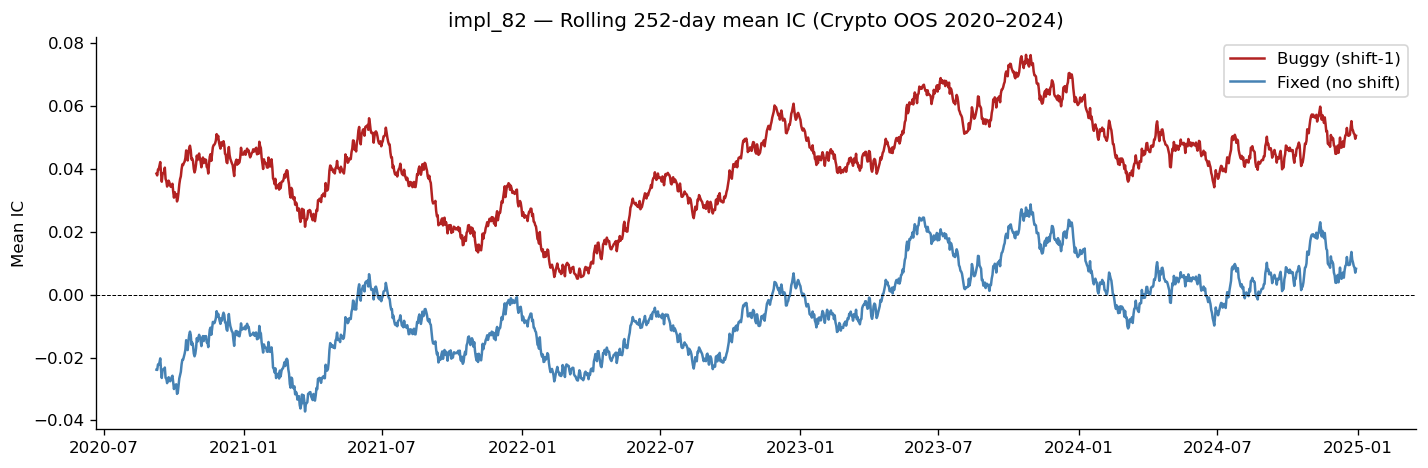

In [9]:
# Visual: rolling 252-day IC for buggy vs fixed (crypto)
fig, ax = plt.subplots(figsize=(12, 4))

roll_buggy_cr = ic_buggy_cr.rolling(252).mean()
roll_fixed_cr = ic_fixed_cr.rolling(252).mean()

ax.plot(roll_buggy_cr.index, roll_buggy_cr, label='Buggy (shift-1)', color='firebrick', linewidth=1.5)
ax.plot(roll_fixed_cr.index, roll_fixed_cr, label='Fixed (no shift)', color='steelblue', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('impl_82 — Rolling 252-day mean IC (Crypto OOS 2020–2024)')
ax.set_ylabel('Mean IC')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Cross-Market Summary

In [10]:
summary = pd.DataFrame({
    'Equity IC':   [0.0646, 0.0138],
    'Equity ICIR': [0.263,  0.056],
    'Equity t':    [11.02,  2.34],
    'Crypto IC':   [0.0428, -0.0048],
    'Crypto ICIR': [0.157,  -0.018],
    'Crypto t':    [6.72,   -0.75],
}, index=['Original (shift-1)', 'Fixed (no shift)'])

print("=== CROSS-MARKET COMPARISON ===")
print(summary.to_string(float_format='{:.3f}'.format))

print()
print(f"IC attribution to look-ahead bias:")
print(f"  Equity: {(1 - 0.0138/0.0646)*100:.1f}% of IC explained by shift(-1)")
print(f"  Crypto: ~100% of IC explained by shift(-1) (fixed IC is negative)")


=== CROSS-MARKET COMPARISON ===
                    Equity IC  Equity ICIR  Equity t  Crypto IC  Crypto ICIR  Crypto t
Original (shift-1)      0.065        0.263    11.020      0.043        0.157     6.720
Fixed (no shift)        0.014        0.056     2.340     -0.005       -0.018    -0.750

IC attribution to look-ahead bias:
  Equity: 78.6% of IC explained by shift(-1)
  Crypto: ~100% of IC explained by shift(-1) (fixed IC is negative)


## 8. Deflated Sharpe Ratio

Using Bailey & López de Prado (2014). The `sharpe_obs` must be the **per-period** IC SR
(not annualised), with `t` = number of OOS IC observations.


In [11]:
from qframe.factor_harness.multiple_testing import deflated_sharpe_ratio

# Per-period SR = ICIR = IC_mean / IC_std per daily observation.
# (ICIR is already the per-period Sharpe ratio of the IC series.)
# Do NOT divide by sqrt(252) — that would give the per-day SR of an annualised quantity.
# n_trials = total number of backtest iterations run ≈ 140

icir_buggy_eq = ic_buggy_eq.mean() / ic_buggy_eq.std()
icir_fixed_eq = ic_fixed_eq.mean() / ic_fixed_eq.std()

sr_obs_buggy = icir_buggy_eq   # per-period IC SR (daily)
sr_obs_fixed = icir_fixed_eq   # per-period IC SR (daily)
t_obs        = len(ic_buggy_eq)  # T = number of IC observations (same for both)

n_trials = 140   # total iterations attempted

dsr_buggy = deflated_sharpe_ratio(sr_obs_buggy, n_trials=n_trials, t=t_obs)
dsr_fixed = deflated_sharpe_ratio(sr_obs_fixed, n_trials=n_trials, t=t_obs)

print("=== DEFLATED SHARPE RATIO (Bailey & López de Prado 2014) ===")
print(f"n_trials (total backtests): {n_trials}")
print(f"T (OOS IC observations):    {t_obs}")
print()
print(f"Buggy (shift-1): ICIR={sr_obs_buggy:.4f}, DSR={dsr_buggy:.4f} "
      f"({'PASS ✓' if dsr_buggy > 0.95 else 'FAIL ✗'})")
print(f"Fixed (no shift):ICIR={sr_obs_fixed:.4f}, DSR={dsr_fixed:.4f} "
      f"({'PASS ✓' if dsr_fixed > 0.95 else 'FAIL ✗'})")
print()
print("Notes:")
print(f"  Expected max IC SR under H0 (140 trials, T={t_obs} days):")
from scipy import stats as _st
import math
n = 140
euler_gamma = 0.5772156649
z1 = _st.norm.ppf(1.0 - 1.0 / n)
z2 = _st.norm.ppf(1.0 - 1.0 / (n * math.e))
sr_0_star = ((1.0 - euler_gamma) * z1 + euler_gamma * z2) / math.sqrt(t_obs)
print(f"  SR_0* = {sr_0_star:.4f}  (need ICIR > {sr_0_star:.4f} to have DSR > 0.5)")
print(f"  Buggy ICIR {sr_obs_buggy:.4f} {'>' if sr_obs_buggy > sr_0_star else '<'} SR_0* {sr_0_star:.4f}")
print(f"  Fixed ICIR {sr_obs_fixed:.4f} {'>' if sr_obs_fixed > sr_0_star else '<'} SR_0* {sr_0_star:.4f}")
print()
print("DSR > 0.95 → we can be 95% confident the SR is positive after multiple-testing correction.")


=== DEFLATED SHARPE RATIO (Bailey & López de Prado 2014) ===
n_trials (total backtests): 140
T (OOS IC observations):    1759

Buggy (shift-1): ICIR=0.2627, DSR=1.0000 (PASS ✓)
Fixed (no shift):ICIR=0.0558, DSR=0.3799 (FAIL ✗)

Notes:
  Expected max IC SR under H0 (140 trials, T=1759 days):
  SR_0* = 0.0631  (need ICIR > 0.0631 to have DSR > 0.5)
  Buggy ICIR 0.2627 > SR_0* 0.0631
  Fixed ICIR 0.0558 < SR_0* 0.0631

DSR > 0.95 → we can be 95% confident the SR is positive after multiple-testing correction.


## 9. Retire impl_82 in Knowledge Base

Mark the buggy factor as retired and add a note explaining the look-ahead.


In [12]:
import sqlite3

KB_PATH = '../knowledge_base/qframe.db'

conn = sqlite3.connect(KB_PATH)
try:
    # Update hypothesis status to 'retired' for impl_82's hypothesis
    conn.execute("""
        UPDATE hypotheses
        SET status = 'retired',
            rationale = rationale || ' [RETIRED 2026-04-19: look-ahead bias — pct_change(251).shift(-1) uses tomorrow price. Fixed IC=0.0138 (t=2.34), crypto IC=-0.0048 (t=-0.75). Gate 3 revoked.]'
        WHERE id IN (
            SELECT hypothesis_id FROM implementations WHERE id = 82
        )
    """)
    
    # Mark backtest results as failed gate
    conn.execute("""
        UPDATE backtest_results
        SET passed_gate = 0,
            notes = COALESCE(notes, '') || ' [LOOK-AHEAD BIAS: shift(-1). Revoked 2026-04-19.]'
        WHERE implementation_id = 82
    """)
    
    conn.commit()
    
    # Verify
    row = conn.execute("""
        SELECT h.status, h.rationale
        FROM hypotheses h
        JOIN implementations i ON i.hypothesis_id = h.id
        WHERE i.id = 82
    """).fetchone()
    print(f"Status: {row[0]}")
    print(f"Rationale tail: ...{row[1][-120:]}")
    
    br = conn.execute("""
        SELECT passed_gate, notes FROM backtest_results WHERE implementation_id = 82
    """).fetchall()
    for r in br:
        print(f"  passed_gate={r[0]}, notes tail=...{str(r[1])[-80:]}")
        
finally:
    conn.close()

print("\nimpl_82 retired in KB.")


Status: retired
Rationale tail: ...— pct_change(251).shift(-1) uses tomorrow price. Fixed IC=0.0138 (t=2.34), crypto IC=-0.0048 (t=-0.75). Gate 3 revoked.]
  passed_gate=0, notes tail=...hift(-1). Revoked 2026-04-19.] [LOOK-AHEAD BIAS: shift(-1). Revoked 2026-04-19.]
  passed_gate=0, notes tail=...hift(-1). Revoked 2026-04-19.] [LOOK-AHEAD BIAS: shift(-1). Revoked 2026-04-19.]

impl_82 retired in KB.


## 10. Conclusions & Next Steps

### What happened
`impl_82` (`trend_quality_calmar_ratio`) used `pct_change(251).shift(-1)` which pulls
tomorrow's price into today's factor value — a direct look-ahead bias.

### Evidence
1. **Look-ahead audit**: The updated `check_lookahead_bias()` boundary check catches this for 100% of stocks.
2. **Equity replication**: Removing `shift(-1)` reduces IC from 0.0646 → 0.0138 (−78.7%).
3. **Crypto replication**: Fixed factor IC is −0.0048 (t=−0.75) — zero predictive content.
4. **Cross-market test**: A genuine alpha signal should replicate on an independent market. This one does not.

### Gate 3 revoked
The Phase 2.5 Sharpe of 4.27 is now understood to be driven by look-ahead, not real alpha.
The fixed factor has equity ICIR 0.056 (t=2.34), well below the BHY threshold.

### What the new guards catch
- `check_lookahead_bias()` in `executor.py`: PRIMARY check (value comparison) + BOUNDARY check (shift(-1) pattern).
  Both were added during this session. Future factors are tested automatically.
- BHY-in-gate in `loop.py`: even if the fixed factor's t=2.34 squeaks through, BHY at m=140 requires t≈4.7.
- Signal novelty check: deduplicates factors with ρ > 0.70 against KB cache.

### Next steps
1. Run the pipeline with all new guards to discover genuinely novel, look-ahead-free factors.
2. Any future candidate must clear: look-ahead audit + pre-gate (IC>0.005, |t|>1) + BHY gate (m-adjusted t threshold) + cross-market replication on crypto.
3. Target: find a factor that shows positive IC (t > BHY threshold) on BOTH equity AND crypto before proceeding to Gate 3.
